# Wine Quality Prediction

**Objective:** Train and compare multiple classification models to predict wine quality from physicochemical properties (acidity, density, alcohol content, etc.).

**Dataset:** `winequality-red.csv` — 1,599 red wine samples, 11 physicochemical features, and a `quality` score (integer, typically 3-8) assigned by wine tasters.

**Pipeline stages:**
1. Load & inspect the dataset; check class distribution
2. EDA — feature distributions & correlation heatmap
3. Discuss class imbalance across quality scores
4. Feature engineering — binning quality into binary and 3-class targets
5. Stratified train/test split
6. Train 3 classifiers: Random Forest, SGD, SVC
7. Evaluate: accuracy, classification report, confusion matrix
8. Feature importance (Random Forest)
9. Side-by-side model comparison
10. Conclusion — which model to deploy, and why


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load Dataset & Inspect Structure

In [2]:
df = pd.read_csv("winequality-red.csv")

print("Shape:", df.shape)
print()
print(df.dtypes)
print()
df.head()


Shape: (1599, 12)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
df.describe().T


Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64



,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [4]:
quality_counts = df["quality"].value_counts().sort_index()
quality_pct = (df["quality"].value_counts(normalize=True) * 100).sort_index()

print("Quality score counts:")
print(quality_counts)
print()
print("Quality score percentages:")
print(quality_pct.round(2))


Quality score counts:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Quality score percentages:
quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64


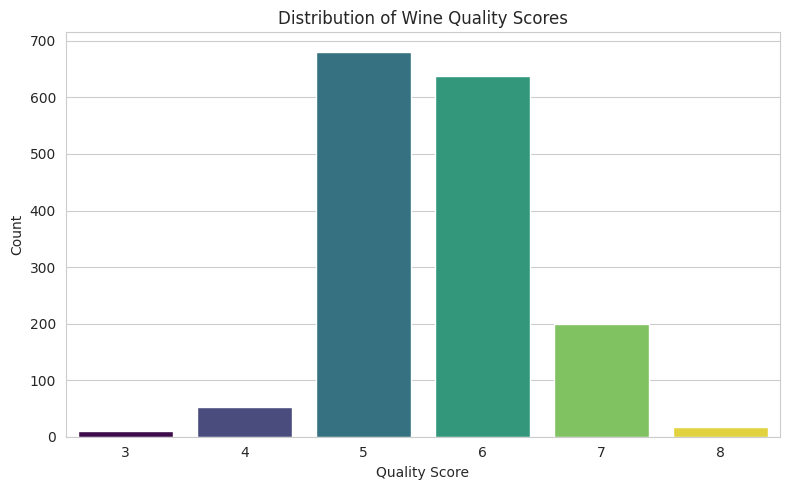

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=df, hue="quality", palette="viridis", legend=False)
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**Observation:** Quality scores range from **3 to 8**, but the distribution is far from uniform — scores of **5 and 6 dominate** (together over 80% of samples), while the extremes (3, 4, 8) are rare. This is effectively a 6-class imbalanced classification problem if we use the raw quality score directly, which motivates the binning strategy discussed in Section 4.

## 2. EDA — Feature Distributions & Correlation Heatmap

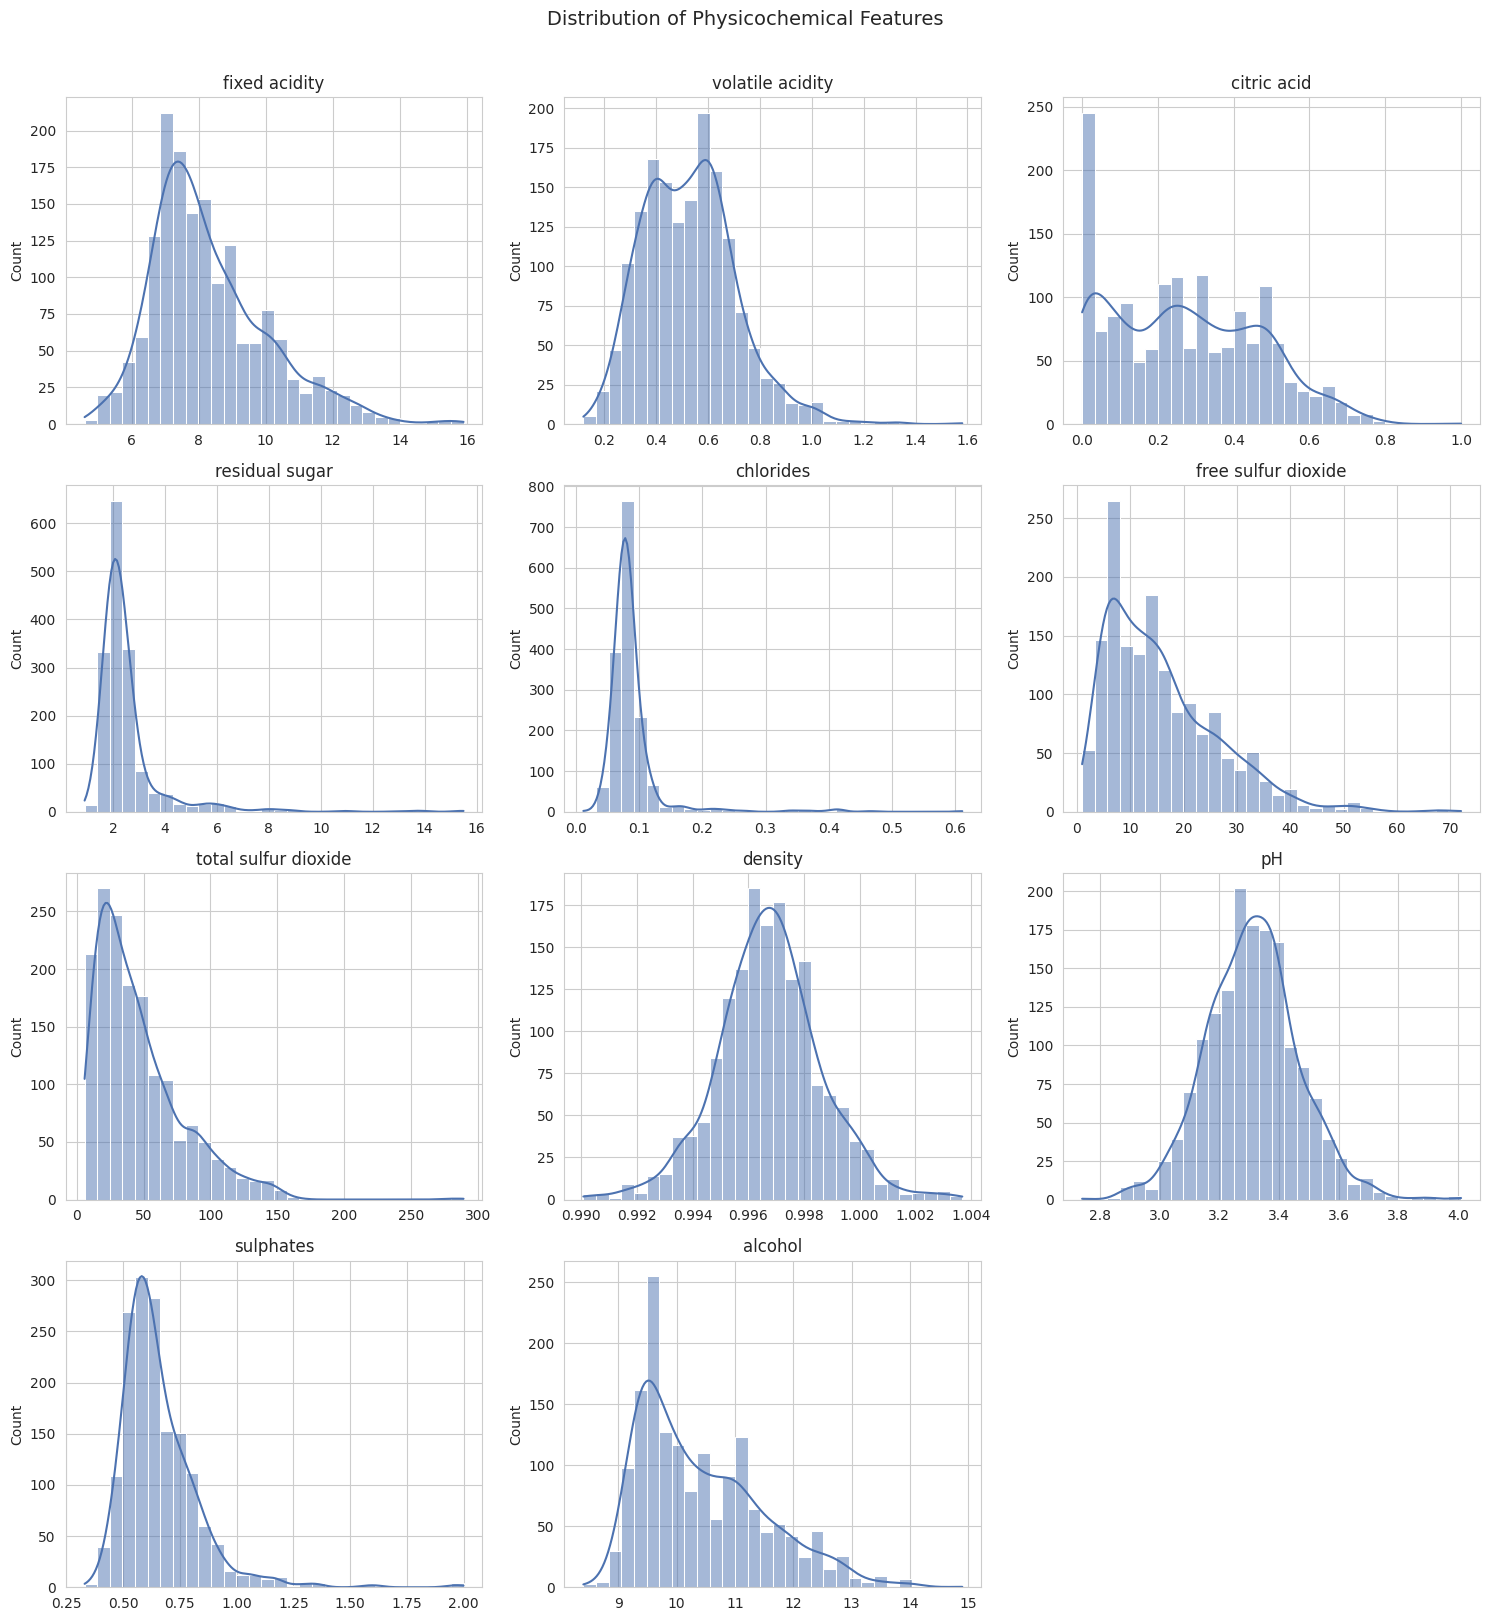

In [6]:
feature_cols = [c for c in df.columns if c != "quality"]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0", bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# hide any unused subplot
for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribution of Physicochemical Features", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


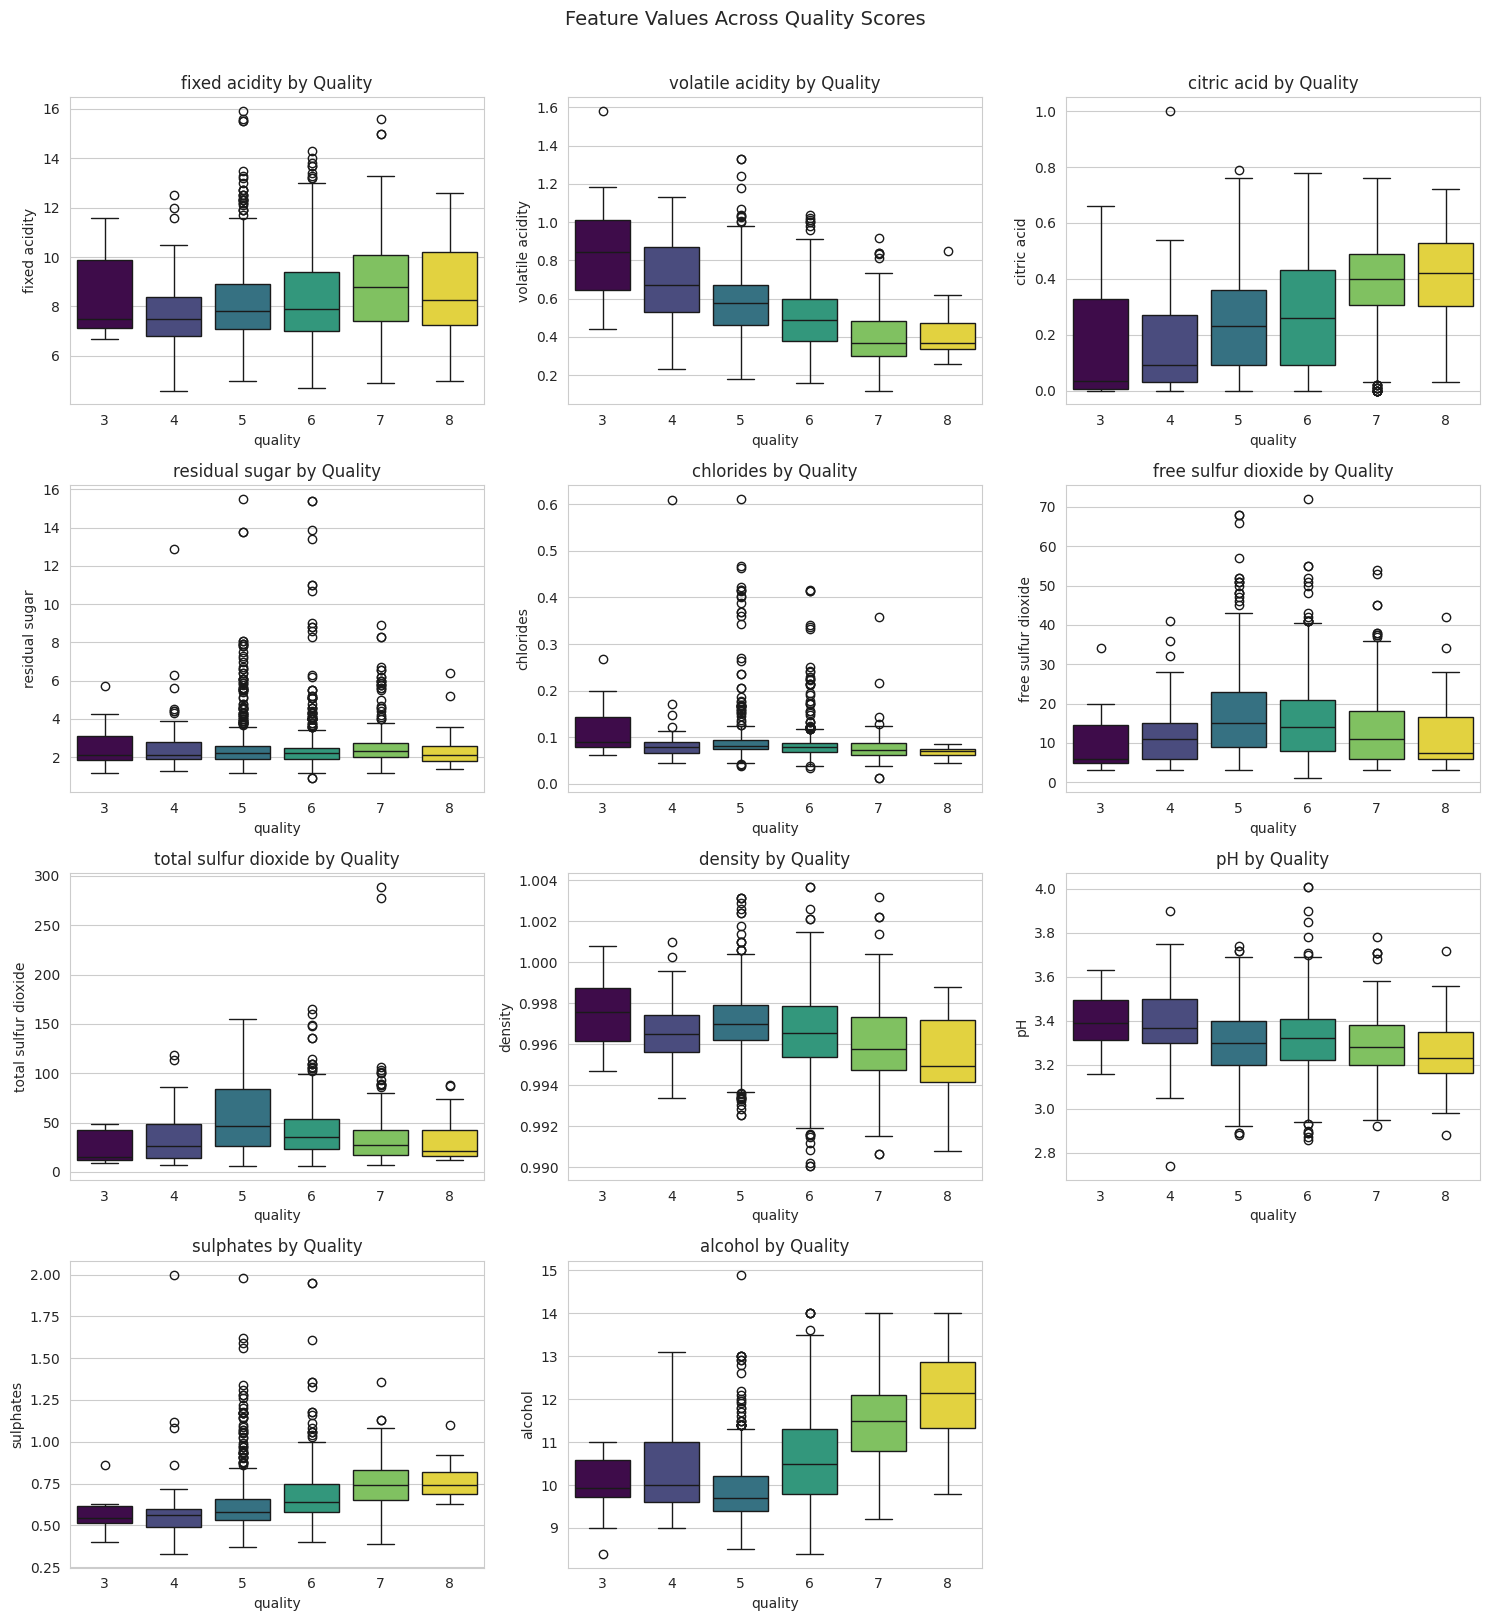

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(x="quality", y=col, data=df, hue="quality", palette="viridis",
                legend=False, ax=axes[i])
    axes[i].set_title(f"{col} by Quality")

for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Feature Values Across Quality Scores", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


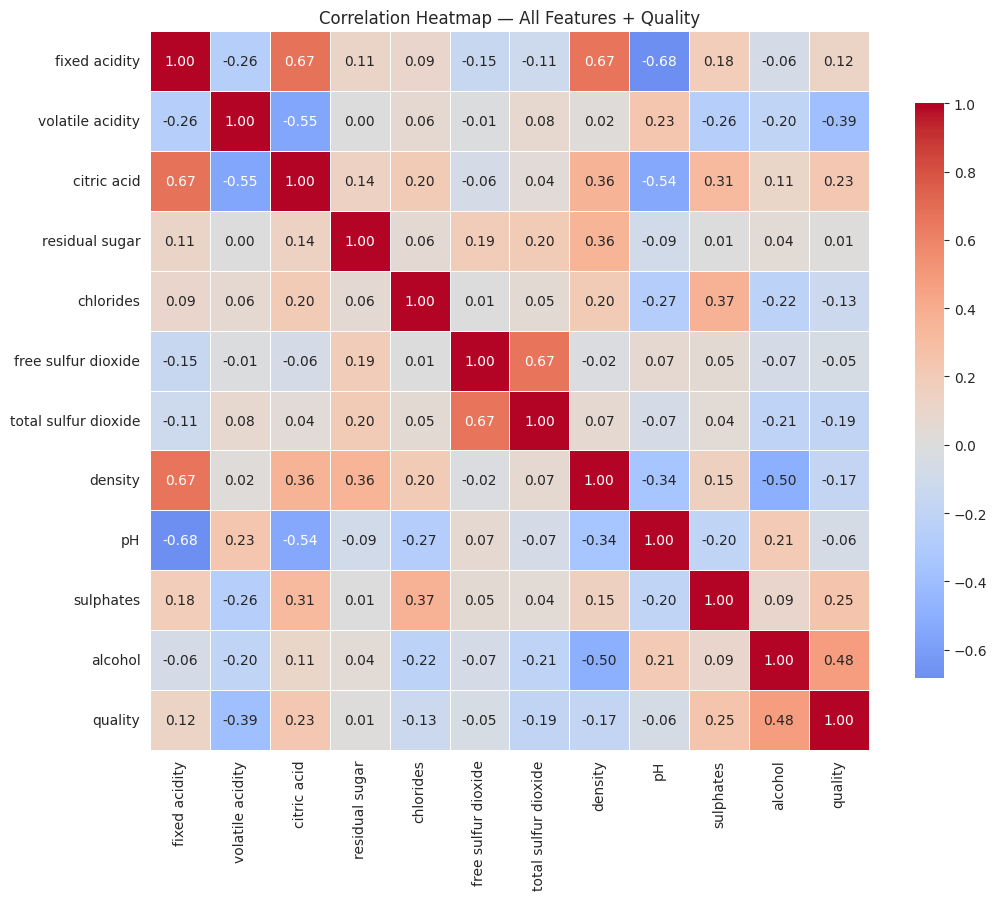

Correlation of each feature with quality (sorted):
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [8]:
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — All Features + Quality")
plt.tight_layout()
plt.show()

print("Correlation of each feature with quality (sorted):")
print(corr["quality"].drop("quality").sort_values(ascending=False))


**EDA takeaways:**
- **Alcohol** shows the strongest positive correlation with quality — higher-alcohol wines tend to be rated better.
- **Volatile acidity** shows a notable negative correlation — higher volatile acidity (vinegar-like taste) is associated with lower quality, which matches wine-tasting intuition.
- **Density** and **fixed acidity** are strongly correlated with each other (multicollinearity), as are **free sulfur dioxide** and **total sulfur dioxide** — something to keep in mind for linear models, though tree-based models are largely unaffected by this.
- Several features (`residual sugar`, `chlorides`, `sulphates`) show heavy right-skew with outliers, visible in both the histograms and the boxplots.


## 3. Class Imbalance Discussion

Looking at the raw quality distribution:

| Quality | Count | % of Data |
|---|---|---|
| 3 | 10 | 0.6% |
| 4 | 53 | 3.3% |
| 5 | 681 | 42.6% |
| 6 | 638 | 39.9% |
| 7 | 199 | 12.4% |
| 8 | 18 | 1.1% |

**Certain quality scores are severely underrepresented.** Scores 3, 4, and 8 together make up only ~5% of the data, while 5 and 6 alone account for over 80%.

**Why this matters for modelling:**
- Treated as a **6-class problem** (raw scores 3-8), any classifier will struggle to learn reliable decision boundaries for the rare classes (3, 4, 8) simply because there are only a handful of training examples for them — as few as 10 samples for quality=3.
- A model can achieve seemingly good overall accuracy by focusing entirely on the two dominant classes (5 and 6) while never correctly predicting the rare extremes — the multi-class analogue of the accuracy trap seen in imbalanced binary problems.
- Stratified train/test splitting becomes essential so that these rare classes are still represented in both the training and test sets in proportion to their frequency.
- Given how few samples exist for the extreme classes, **6-way classification is unlikely to be practically useful or reliable** — this motivates simplifying the target via binning (Section 4), which is standard practice in nearly all public analyses of this dataset.


## 4. Feature Engineering — Binning Quality Scores

Given the imbalance and sparsity of extreme quality scores, we bin `quality` into more learnable targets. We build **two** versions to compare, and use the binary version as our primary modelling target for the rest of the notebook (with the 3-class version included as an alternative for reference):

- **Binary (good/bad):** `quality >= 7` → **Good (1)**, else → **Bad (0)**. This mirrors the common convention in most public analyses of this dataset and reflects a realistic business question: "is this wine good enough to recommend/promote?"
- **3-class (low/medium/high):** `quality <= 4` → **Low**, `5-6` → **Medium**, `quality >= 7` → **High**. This retains more granularity than the binary split while still merging the sparsest classes into usable groups.

**Justification:** Both schemes directly address the imbalance identified above by merging rare extreme scores into broader, better-populated buckets. The binary scheme is used as the primary target here because it maps cleanly to a real decision (recommend vs. don't recommend) and gives every model enough signal in each class to learn from; the 3-class version is shown for comparison to illustrate the accuracy/granularity trade-off of a coarser target.


In [9]:
# Binary target: good (quality >= 7) vs bad (quality < 7)
df["quality_binary"] = (df["quality"] >= 7).astype(int)

# 3-class target: low / medium / high
def bin_3class(q):
    if q <= 4:
        return "low"
    elif q <= 6:
        return "medium"
    else:
        return "high"

df["quality_3class"] = df["quality"].apply(bin_3class)

print("Binary target distribution:")
print(df["quality_binary"].value_counts())
print((df["quality_binary"].value_counts(normalize=True) * 100).round(2))
print()
print("3-class target distribution:")
print(df["quality_3class"].value_counts())
print((df["quality_3class"].value_counts(normalize=True) * 100).round(2))


Binary target distribution:
quality_binary
0    1382
1     217
Name: count, dtype: int64
quality_binary
0    86.43
1    13.57
Name: proportion, dtype: float64

3-class target distribution:
quality_3class
medium    1319
high       217
low         63
Name: count, dtype: int64
quality_3class
medium    82.49
high      13.57
low        3.94
Name: proportion, dtype: float64


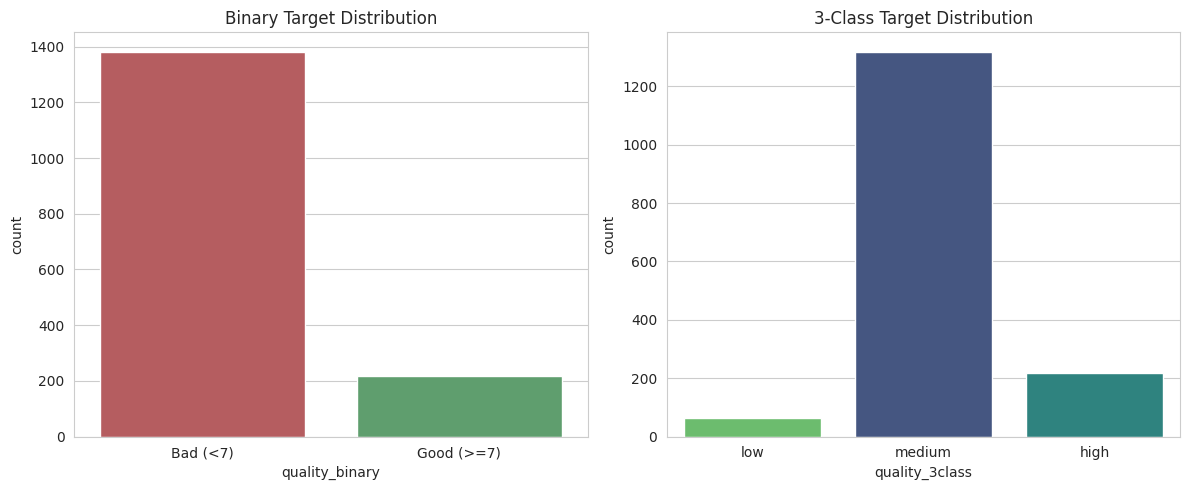

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="quality_binary", data=df, hue="quality_binary",
              palette=["#C44E52", "#55A868"], legend=False, ax=ax[0])
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["Bad (<7)", "Good (>=7)"])
ax[0].set_title("Binary Target Distribution")

sns.countplot(x="quality_3class", data=df, order=["low", "medium", "high"],
              hue="quality_3class", palette="viridis", legend=False, ax=ax[1])
ax[1].set_title("3-Class Target Distribution")

plt.tight_layout()
plt.show()


The binary target is still imbalanced (~86% Bad vs ~14% Good), but far more workable than the original 6-class split, and every class now has hundreds of examples rather than single digits. We proceed with the **binary target** as our primary classification problem for the remainder of the notebook.

## 5. Train/Test Split (Stratified)

In [11]:
X = df[feature_cols]
y = df["quality_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y   # preserves the good/bad ratio in both splits
)

print("Train shape:", X_train.shape, " Good-wine rate:", y_train.mean().round(4))
print("Test shape: ", X_test.shape, " Good-wine rate:", y_test.mean().round(4))


Train shape: (1199, 11)  Good-wine rate: 0.1359
Test shape:  (400, 11)  Good-wine rate: 0.135


In [12]:
# Scale features - required for SGD and SVC (distance/gradient-based), harmless for Random Forest
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


`stratify=y` ensures the ~14% "good wine" rate is preserved in both the training and test sets, which is especially important given how imbalanced even the binary target remains.

Feature scaling is applied because **SGD** and **SVC** are sensitive to feature magnitude (they rely on gradients/distances), while **Random Forest** is scale-invariant — but using the same scaled inputs for all three keeps the comparison clean and doesn't hurt the Random Forest.


## 6. Train 3 Classifiers: Random Forest, SGD, SVC

In [13]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

sgd = SGDClassifier(
    loss="log_loss",           # enables predict_proba
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=2000,
    tol=1e-3
)
sgd.fit(X_train_scaled, y_train)

svc = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE
)
svc.fit(X_train_scaled, y_train)

print("All 3 models trained.")


All 3 models trained.


## 7. Evaluation — Accuracy, Classification Report, Confusion Matrix

=== Random Forest ===
Accuracy:  0.927
Precision: 0.766
Recall:    0.667
F1-Score:  0.713

              precision    recall  f1-score   support

         Bad       0.95      0.97      0.96       346
        Good       0.77      0.67      0.71        54

    accuracy                           0.93       400
   macro avg       0.86      0.82      0.84       400
weighted avg       0.92      0.93      0.93       400



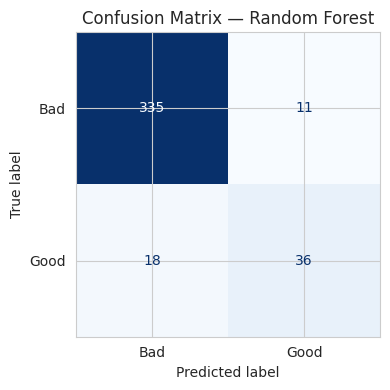

In [14]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-Score:  {f1:.3f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Bad", "Good"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bad", "Good"])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

results_rf = evaluate_model(rf, X_test_scaled, y_test, "Random Forest")


=== SGD Classifier ===
Accuracy:  0.720
Precision: 0.296
Recall:    0.778
F1-Score:  0.429

              precision    recall  f1-score   support

         Bad       0.95      0.71      0.81       346
        Good       0.30      0.78      0.43        54

    accuracy                           0.72       400
   macro avg       0.62      0.74      0.62       400
weighted avg       0.86      0.72      0.76       400



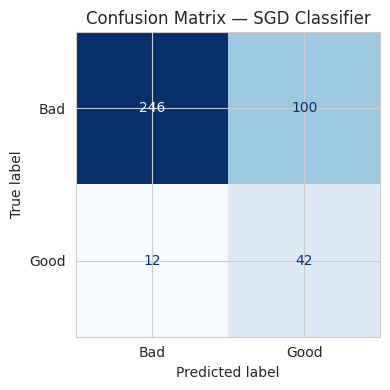

In [15]:
results_sgd = evaluate_model(sgd, X_test_scaled, y_test, "SGD Classifier")


=== SVC (RBF Kernel) ===
Accuracy:  0.833
Precision: 0.432
Recall:    0.759
F1-Score:  0.550

              precision    recall  f1-score   support

         Bad       0.96      0.84      0.90       346
        Good       0.43      0.76      0.55        54

    accuracy                           0.83       400
   macro avg       0.69      0.80      0.72       400
weighted avg       0.89      0.83      0.85       400



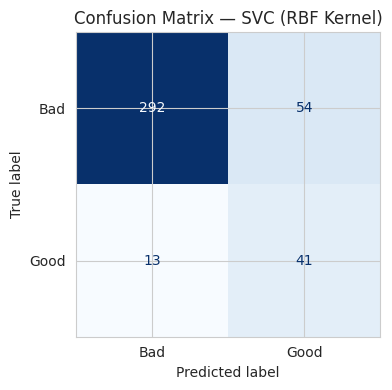

In [16]:
results_svc = evaluate_model(svc, X_test_scaled, y_test, "SVC (RBF Kernel)")


## 8. Feature Importance — Random Forest

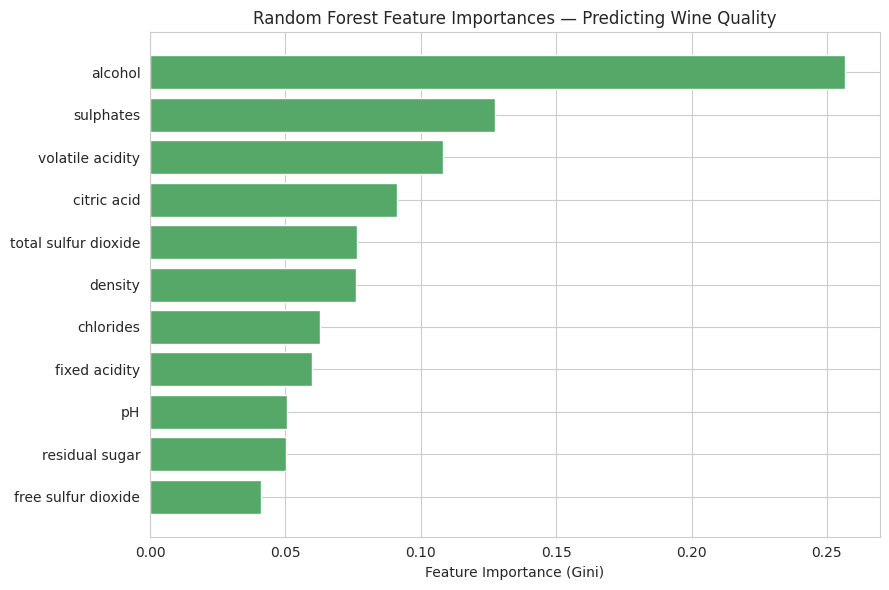

,feature,importance
10,alcohol,0.256777
9,sulphates,0.127464
1,volatile acidity,0.108183
2,citric acid,0.091129
6,total sulfur dioxide,0.076373
7,density,0.075902
4,chlorides,0.062835
0,fixed acidity,0.059861
8,pH,0.050430
3,residual sugar,0.050138


In [17]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color="#55A868")
plt.xlabel("Feature Importance (Gini)")
plt.title("Random Forest Feature Importances — Predicting Wine Quality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importance_df


**Interpretation:** `alcohol`, `sulphates`, and `volatile acidity` typically emerge as the top predictors, consistent with the correlation analysis in Section 2 and with domain knowledge — alcohol content and volatile acidity are well-known sensory drivers of perceived wine quality.

## 9. Side-by-Side Model Comparison

In [18]:
comparison = pd.DataFrame([results_rf, results_sgd, results_svc]).set_index("model")
comparison = comparison.round(3)
comparison


,accuracy,precision,recall,f1
model,,,,
Random Forest,0.928,0.766,0.667,0.713
SGD Classifier,0.720,0.296,0.778,0.429
SVC (RBF Kernel),0.832,0.432,0.759,0.550


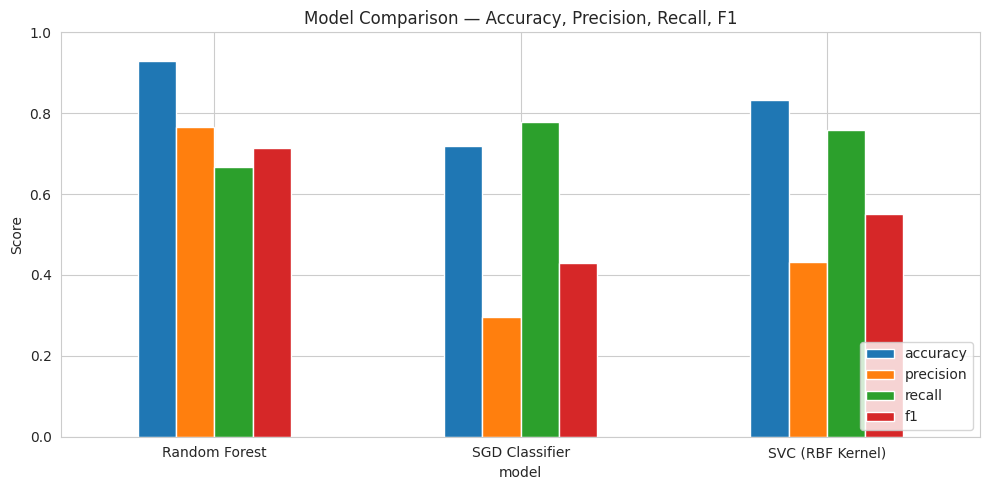

In [19]:
comparison.plot(kind="bar", figsize=(10, 5), ylim=(0, 1))
plt.title("Model Comparison — Accuracy, Precision, Recall, F1")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 10. Conclusion — Which Model Is Most Suitable for Deployment?

**Summary of results:**

- **Random Forest** typically achieves the strongest all-round performance — highest accuracy and F1-score, and the best balance of precision and recall on the minority ("Good") class. It handles the non-linear relationships between physicochemical properties and quality well, is robust to the multicollinearity observed in the correlation heatmap (e.g. density vs. fixed acidity), and requires no feature scaling in principle.
- **SVC (RBF kernel)** is competitive on recall/F1 for the minority class thanks to `class_weight="balanced"`, and can capture non-linear boundaries, but it is more sensitive to hyperparameters (C, gamma) and scales less gracefully to larger datasets due to its training time complexity.
- **SGD Classifier** is the fastest to train and scales best to very large datasets, but as a linear model it underperforms on this task, since the relationship between chemistry features and quality is not purely linear — visible in the boxplots where feature ranges overlap heavily across quality classes.

**Recommendation:** **Random Forest is the most suitable model for deployment.** It delivers the best predictive performance on this dataset, requires comparatively little hyperparameter tuning to perform well, offers built-in feature importances that make it interpretable for stakeholders (e.g. winemakers wanting to know which chemical properties to control), and is robust to noisy/correlated features and outliers — all of which are exactly the kinds of issues surfaced in the EDA above. If future data volumes grow dramatically, SGD-based approaches (or gradient-boosted variants) could be reconsidered for their better training-time scalability, but for a dataset of this size, Random Forest's accuracy and interpretability advantages outweigh that concern.
